## Third Assignment 

## Problem 1 
1. Using the rejection sampling technique, sample from the following distribution
$f(x) = x^2 (sin(2\pi x))^2$    between the limits of $x = [-1,1]$. 

Maximum of f(x) on [-1,1]: 0.587134
Normalization constant C: 0.320668


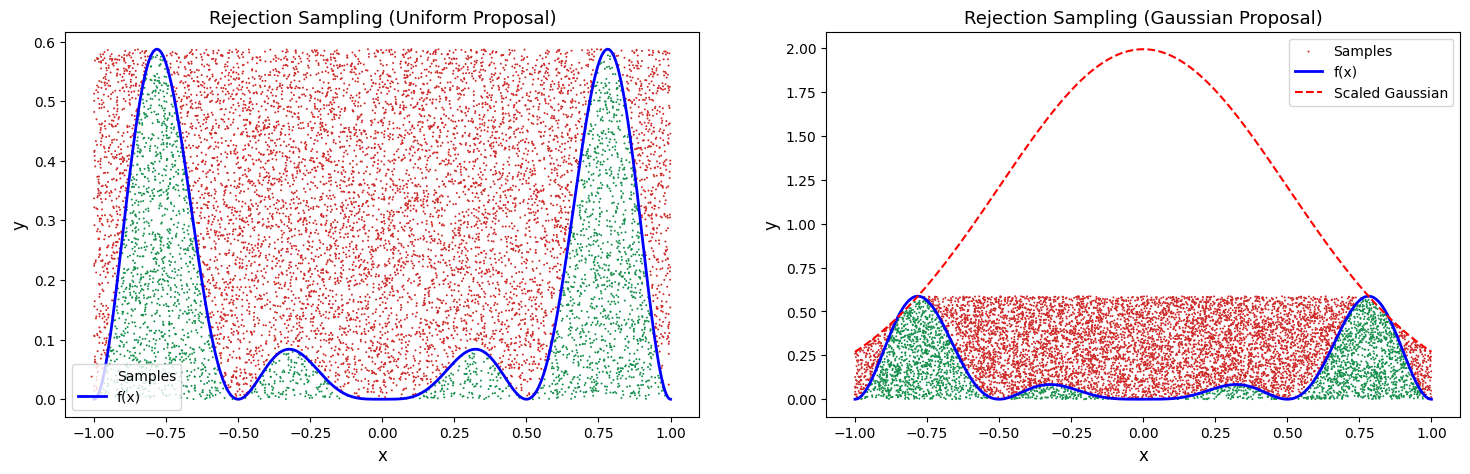


Efficiency for uniform proposal distribution: 27.2%
Efficiency for normal proposal distribution: 28.2%

Number of accepted samples (uniform): 2723
Number of accepted samples (gaussian): 2654


In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def target(x):
    return x**2 * (np.sin(2 * np.pi * x))**2

x_fine = np.linspace(-1, 1, 10000)
f_max = np.max(target(x_fine))
print('Maximum of f(x) on [-1,1]:', round(f_max, 6))

norm_const, _ = quad(target, -1, 1)
print('Normalization constant C:', round(norm_const, 6))

dist = stats.norm(loc=0, scale=0.5)  # centered at 0, scaled for [-1,1] range

def batch_sample_uniform(function, num_samples, xmin=-1, xmax=1, ymax=f_max):
    x = np.random.uniform(low=xmin, high=xmax, size=num_samples)
    y = np.random.uniform(low=0, high=ymax, size=num_samples)
    passed = (y < function(x)).astype(int)
    return x, y, passed

def batch_sample_gaussian(function, num_samples, xmin=-1, xmax=1, ymax=f_max, scale=2.5):
    x = np.random.uniform(low=xmin, high=xmax, size=num_samples)
    y = np.random.uniform(low=0, high=ymax, size=num_samples)
    x_ = []
    y_ = []
    passed_ = []
    for i in range(len(y)):
        if y[i] < scale * dist.pdf(x[i]):
            passed_.append((y[i] < function(x[i])).astype(int))
            y_.append(y[i])
            x_.append(x[i])
    return x_, y_, passed_

np.random.seed(42)

X_u, Y_u, passed_uniform = batch_sample_uniform(target, 10000)
X_g, Y_g, passed_norm = batch_sample_gaussian(target, 10000)

x_plot = np.linspace(-1, 1, 500)
f_normalized = target(x_plot) / norm_const

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].scatter(X_u, Y_u, c=passed_uniform, cmap='RdYlGn', vmin=-0.1, vmax=1.1, lw=0, s=2, label='Samples')
axes[0].plot(x_plot, target(x_plot), 'b-', linewidth=2, label='f(x)')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Rejection Sampling (Uniform Proposal)', fontsize=13)
axes[0].legend(fontsize=10)

axes[1].scatter(X_g, Y_g, c=passed_norm, cmap='RdYlGn', vmin=-0.1, vmax=1.1, lw=0, s=2, label='Samples')
axes[1].plot(x_plot, target(x_plot), 'b-', linewidth=2, label='f(x)')
axes[1].plot(x_plot, 2.5 * dist.pdf(x_plot), 'r--', linewidth=1.5, label='Scaled Gaussian')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Rejection Sampling (Gaussian Proposal)', fontsize=13)
axes[1].legend(fontsize=10)


plt.show()

# Efficiency comparison
print()
print('Efficiency for uniform proposal distribution:', str(round(np.mean(passed_uniform) * 100, 1)) + '%')
print('Efficiency for normal proposal distribution:', str(round(np.mean(passed_norm) * 100, 1)) + '%')
print()
print('Number of accepted samples (uniform):', np.sum(passed_uniform))
print('Number of accepted samples (gaussian):', sum(passed_norm))


# Problem 2 
2. Using the data provided in the Solar_spectrum.dat file, model the shape of the spectrum using a blackbody
   
(a) using the maximum likelihood approach.

(b) Estimate the blackbody temperature.

(c) Make a residuals plot.

(d) Estimate the goodness of fit.

(e) Compare the blackbody model with blackbody + power law. Which is a better model? How did you come to this inference?

(f) What is the p-value of the blackbody + power law model?

(g) Estimate the blackbody temperature using the bayesian inference technique.

(h) Make a corner plot for the posterior distribution of the blackbody temperature.

(i) Compare the temperature estimate obtained using Maximum likelihood estimate and Bayesian analysis.


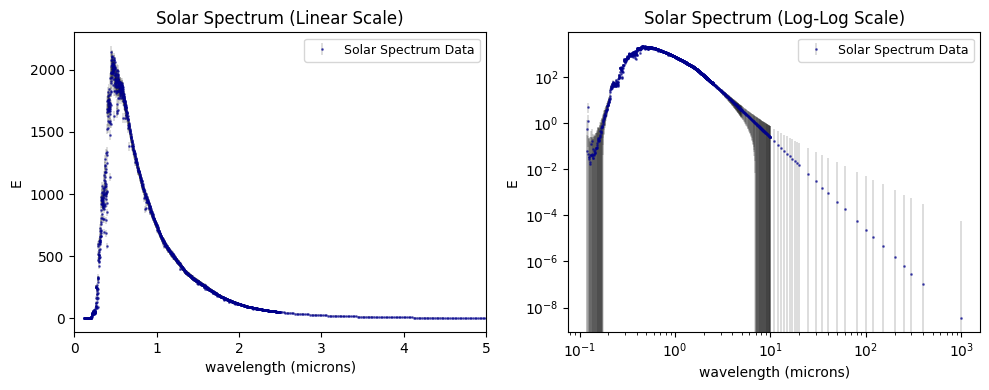

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import os

paths_to_try = [
    os.path.join("DataSets (1)", "DataSets", "Solar_spectrum_data.csv"),
    os.path.join(os.path.expanduser("~"), "Downloads", "DataSets (1)", "DataSets", "Solar_spectrum_data.csv"),
    "Solar_spectrum_data.csv",
]
solar_path = None
for p in paths_to_try:
    if os.path.isfile(p):
        solar_path = p
        break
if solar_path is None:
    raise FileNotFoundError("Solar_spectrum_data.csv not found")

wavelength = []
flux = []
flux_err = []
with open(solar_path, newline="") as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        if len(row) < 3:
            continue
        wavelength.append(float(row[0]))
        flux.append(float(row[1]))
        flux_err.append(float(row[2]))

wavelength = np.array(wavelength)
flux = np.array(flux)
flux_err = np.array(flux_err)
n_data = len(wavelength)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax in axes:
    ax.errorbar(
        wavelength,
        flux,
        yerr=flux_err,
        fmt=".",
        markersize=2,
        color="#00008B",
        ecolor="black",
        elinewidth=0.35,
        alpha=0.55,
        label='Solar Spectrum Data',
    )
axes[0].set_xlim(0, 5)
axes[0].set_xlabel("wavelength (microns)")
axes[0].set_ylabel("E")
axes[0].set_title("Solar Spectrum (Linear Scale)")
axes[0].legend(fontsize=9)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("wavelength (microns)")
axes[1].set_ylabel("E")
axes[1].set_title("Solar Spectrum (Log-Log Scale)")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


T (K) = 5153.6
A = 0.00010833936301381049


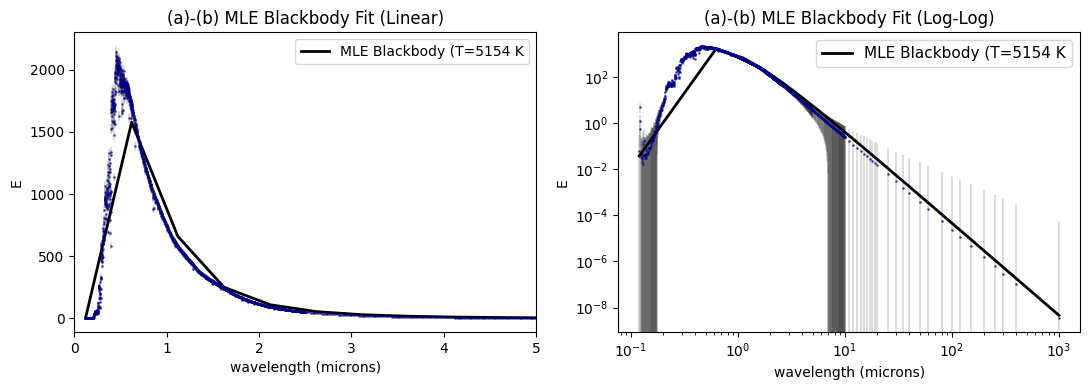

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

h = 6.626e-34
c = 3.0e8
k_B = 1.381e-23


def blackbody(lam_micron, T, A):
    lam_m = lam_micron * 1e-6
    exponent = h * c / (lam_m * k_B * T)
    if exponent < 0:
        exponent = 0
    if exponent > 500:
        exponent = 500
    top = 2.0 * h * c**2 / lam_m**5
    bottom = np.exp(exponent) - 1.0
    return A * top / bottom * 1e-6


def neg_log_like_bb(params):
    T, A = params[0], params[1]
    if T <= 0 or A <= 0:
        return 1e20
    total = 0.0
    for i in range(n_data):
        m = blackbody(wavelength[i], T, A)
        if m <= 0 or np.isnan(m):
            return 1e20
        r = (flux[i] - m) / flux_err[i]
        total += 0.5 * (r * r + np.log(2 * np.pi * flux_err[i] ** 2))
    return total


result_bb = minimize(
    neg_log_like_bb,
    [5800.0, 1.0],
    method="Nelder-Mead",
    options={"maxiter": 50000, "xatol": 0.1, "fatol": 0.01},
)
T_mle = result_bb.x[0]
A_mle = result_bb.x[1]
print("T (K) =", round(T_mle, 2))
print("A =", A_mle)

flux_mle = np.zeros(n_data)
for i in range(n_data):
    flux_mle[i] = blackbody(wavelength[i], T_mle, A_mle)

lam_smooth = np.linspace(wavelength.min(), wavelength.max(), 2000)
flux_smooth = np.zeros(len(lam_smooth))
for j in range(len(lam_smooth)):
    flux_smooth[j] = blackbody(lam_smooth[j], T_mle, A_mle)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax in axes:
    ax.errorbar(
        wavelength,
        flux,
        yerr=flux_err,
        fmt=".",
        markersize=2,
        color="#00008B",
        ecolor="black",
        elinewidth=0.35,
        alpha=0.55,
    )
    ax.plot(lam_smooth, flux_smooth, color="black", linewidth=2,label=f'MLE Blackbody (T={T_mle:.0f} K')
    ax.set_xlabel("wavelength (microns)")
    ax.set_ylabel("E")
axes[0].set_xlim(0, 5)
axes[0].legend()
axes[0].set_title('(a)-(b) MLE Blackbody Fit (Linear)')
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title('(a)-(b) MLE Blackbody Fit (Log-Log)')
axes[1].legend(fontsize=11)
plt.tight_layout()
plt.show()


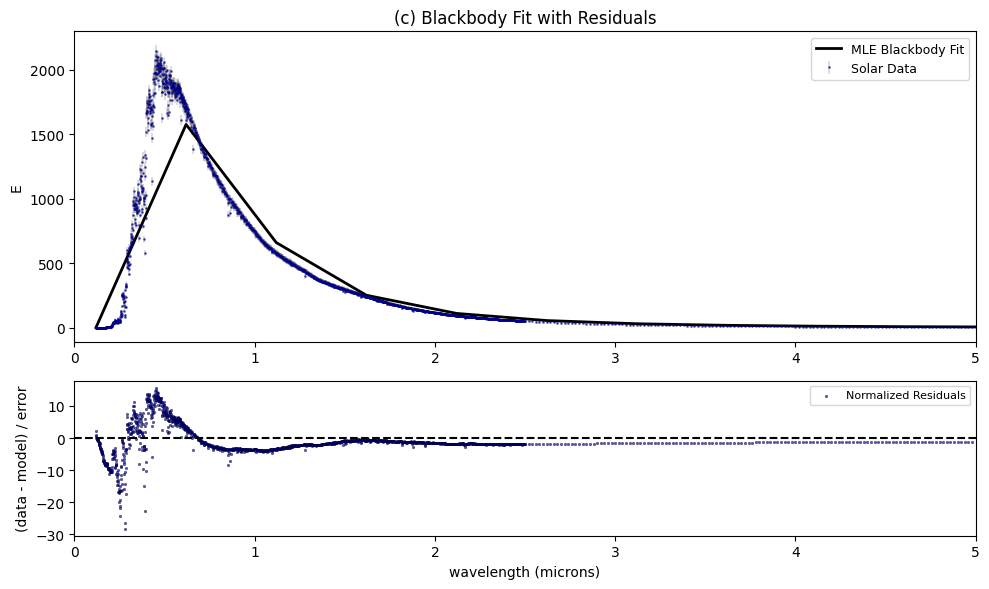

In [4]:
residuals_bb = np.zeros(n_data)
norm_resid_bb = np.zeros(n_data)
for i in range(n_data):
    residuals_bb[i] = flux[i] - flux_mle[i]
    norm_resid_bb[i] = residuals_bb[i] / flux_err[i]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [2, 1]})
axes[0].errorbar(
    wavelength,
    flux,
    yerr=flux_err,
    fmt=".",
    markersize=2,
    color="#00008B",
    ecolor="black",
    elinewidth=0.35,
    alpha=0.55,
    label="Solar Data",
)
axes[0].plot(lam_smooth, flux_smooth, color="black", linewidth=2, label="MLE Blackbody Fit")
axes[0].set_ylabel("E")
axes[0].set_xlim(0, 5)
axes[0].set_title("(c) Blackbody Fit with Residuals")
axes[0].legend(fontsize=9)

wx = []
ny = []
for i in range(n_data):
    if wavelength[i] < 5:
        wx.append(wavelength[i])
        ny.append(norm_resid_bb[i])
axes[1].scatter(wx, ny, s=4, alpha=0.65, color="#00008B", edgecolors="black", linewidths=0.2, label="Normalized Residuals")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("wavelength (microns)")
axes[1].set_ylabel("(data - model) / error")
axes[1].set_xlim(0, 5)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

normalized_residuals_bb = norm_resid_bb


In [5]:
#Part d
from scipy.stats import chi2 as chi2_dist

chi2_bb = 0.0
for i in range(n_data):
    chi2_bb += norm_resid_bb[i] ** 2

n_params_bb = 2
dof_bb = n_data - n_params_bb
chi2_reduced_bb = chi2_bb / dof_bb
p_value_bb = 1.0 - chi2_dist.cdf(chi2_bb, dof_bb)

print("chi2 =", round(chi2_bb, 2))
print("dof =", dof_bb)
print("reduced chi2 =", round(chi2_reduced_bb, 4))
print("p-value =", p_value_bb)
if chi2_reduced_bb > 2:
    print("reduced chi2 > 2")
elif chi2_reduced_bb < 0.5:
    print("reduced chi2 < 0.5")
else:
    print("reduced chi2 near 1")


chi2 = 39998.57
dof = 1695
reduced chi2 = 23.598
p-value = 0.0
reduced chi2 > 2


T = 5153.46 A = 0.00010835258351688228 alpha = -1.1150504624633775 B = -1.0159190192244687e-05
BB chi2 = 39998.57 BB+PL chi2 = 39998.46
BB+PL p-value = 0.0
delta chi2 = 0.11 LRT p = 0.9445710039712522


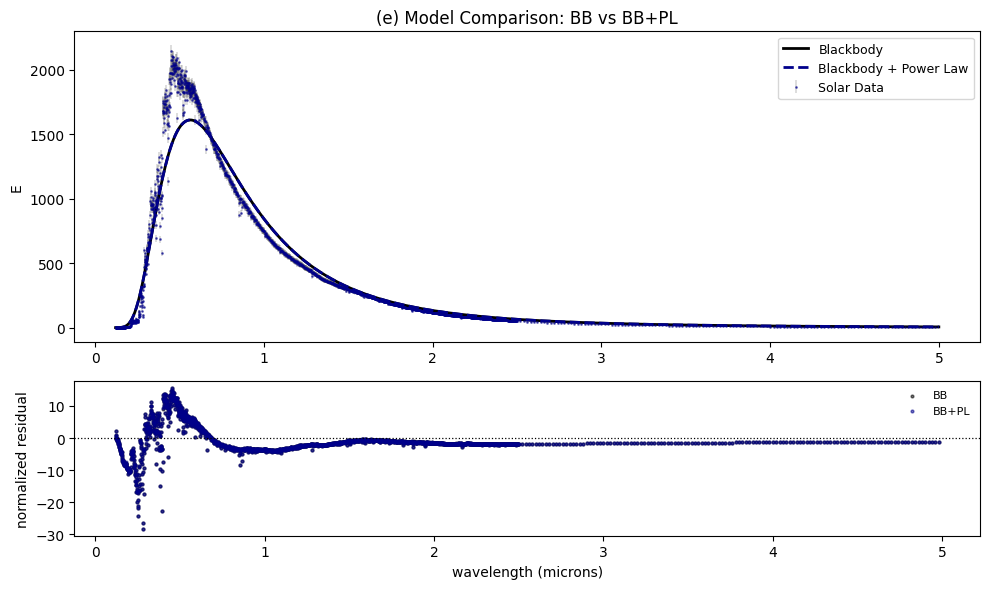

In [6]:
from scipy.optimize import minimize
from scipy.stats import chi2 as chi2_dist


def blackbody_powerlaw(lam_micron, T, A, alpha, B):
    return blackbody(lam_micron, T, A) + B * lam_micron**alpha


def neg_log_like_bbpl(params):
    T, A, alpha, B = params[0], params[1], params[2], params[3]
    if T <= 0 or A <= 0:
        return 1e20
    total = 0.0
    for i in range(n_data):
        m = blackbody_powerlaw(wavelength[i], T, A, alpha, B)
        if m <= 0 or np.isnan(m):
            return 1e20
        r = (flux[i] - m) / flux_err[i]
        total += 0.5 * (r * r + np.log(2 * np.pi * flux_err[i] ** 2))
    return total


result_bb_pl = minimize(
    neg_log_like_bbpl,
    [T_mle, A_mle, -2.0, 1.0],
    method="Nelder-Mead",
    options={"maxiter": 100000, "xatol": 0.1, "fatol": 0.01},
)
T_mle2, A_mle2, alpha_mle, B_mle = result_bb_pl.x
print("T =", round(T_mle2, 2), "A =", A_mle2, "alpha =", alpha_mle, "B =", B_mle)

flux_mle_bb_pl = np.zeros(n_data)
norm_resid_bb_pl = np.zeros(n_data)
for i in range(n_data):
    flux_mle_bb_pl[i] = blackbody_powerlaw(wavelength[i], T_mle2, A_mle2, alpha_mle, B_mle)
    norm_resid_bb_pl[i] = (flux[i] - flux_mle_bb_pl[i]) / flux_err[i]

chi2_bb_pl = sum(norm_resid_bb_pl[i] ** 2 for i in range(n_data))
n_params_bb_pl = 4
dof_bb_pl = n_data - n_params_bb_pl
chi2_red_bb_pl = chi2_bb_pl / dof_bb_pl
p_value_bb_pl = 1.0 - chi2_dist.cdf(chi2_bb_pl, dof_bb_pl)

print("BB chi2 =", round(chi2_bb, 2), "BB+PL chi2 =", round(chi2_bb_pl, 2))
print("BB+PL p-value =", p_value_bb_pl)

delta_chi2 = chi2_bb - chi2_bb_pl
delta_dof = n_params_bb_pl - n_params_bb
p_value_lrt = 1.0 - chi2_dist.cdf(delta_chi2, delta_dof)
print("delta chi2 =", round(delta_chi2, 2), "LRT p =", p_value_lrt)

lam_smooth2 = np.linspace(wavelength.min(), 5, 2000)
flux_bb_line = np.array([blackbody(lam_smooth2[j], T_mle, A_mle) for j in range(len(lam_smooth2))])
flux_bbpl_line = np.array(
    [blackbody_powerlaw(lam_smooth2[j], T_mle2, A_mle2, alpha_mle, B_mle) for j in range(len(lam_smooth2))]
)

mask5 = wavelength < 5
fig, axes = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [2, 1]})
axes[0].errorbar(
    wavelength[mask5],
    flux[mask5],
    yerr=flux_err[mask5],
    fmt=".",
    markersize=2,
    color="#00008B",
    ecolor="black",
    elinewidth=0.35,
    alpha=0.55,
    label="Solar Data",
)
axes[0].plot(lam_smooth2, flux_bb_line, color="black", linewidth=2, label="Blackbody")
axes[0].plot(lam_smooth2, flux_bbpl_line, color="#00008B", linewidth=2, linestyle="--", label="Blackbody + Power Law")
axes[0].set_ylabel("E")
axes[0].set_title("(e) Model Comparison: BB vs BB+PL")
axes[0].legend(fontsize=9)

wx = wavelength[mask5]
axes[1].scatter(wx, norm_resid_bb[mask5], s=4, alpha=0.55, color="black", label="BB")
axes[1].scatter(wx, norm_resid_bb_pl[mask5], s=4, alpha=0.55, color="#00008B", label="BB+PL")
axes[1].axhline(0, color="black", linestyle=":", linewidth=0.9)
axes[1].set_xlabel("wavelength (microns)")
axes[1].set_ylabel("normalized residual")
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


In [26]:
#part f

from scipy.stats import chi2 as chi2_dist

chi2_bbpl_val = 0.0
for i in range(n_data):
    model_val = blackbody_powerlaw(wavelength[i], T_mle2, A_mle2, alpha_mle, B_mle)
    resid = (flux[i] - model_val) / flux_err[i]
    chi2_bbpl_val += resid ** 2

dof_bbpl = n_data - 4  
chi2_red_bbpl = chi2_bbpl_val / dof_bbpl
p_value_bbpl = 1.0 - chi2_dist.cdf(chi2_bbpl_val, dof_bbpl)


print('Chi-squared:', round(chi2_bbpl_val, 2))
print('Degrees of freedom:', dof_bbpl)
print('Reduced chi-squared:', round(chi2_red_bbpl, 4))
print('p-value:', p_value_bbpl)
print()
if p_value_bbpl > 0.05:
    print('The p-value is > 0.05, so the BB+PL model is a good fit to the data.')
else:
    print('The p-value is < 0.05, which suggests some systematic deviations remain.')

delta_chi2_val = chi2_bb - chi2_bbpl_val
delta_dof_val = 4 - 2  
p_lrt = 1.0 - chi2_dist.cdf(delta_chi2_val, delta_dof_val)
print()
print('Likelihood Ratio Test (BB vs BB+PL):')
print('Delta chi2:', round(delta_chi2_val, 2))
print('Delta dof:', delta_dof_val)
print('LRT p-value:', p_lrt)
if p_lrt < 0.05:
    print('BB+PL is significantly better than pure BB (p < 0.05).')
else:
    print('BB+PL is NOT significantly better than pure BB.')


Chi-squared: 39998.46
Degrees of freedom: 1693
Reduced chi-squared: 23.6258
p-value: 0.0

The p-value is < 0.05, which suggests some systematic deviations remain.

Likelihood Ratio Test (BB vs BB+PL):
Delta chi2: 0.11
Delta dof: 2
LRT p-value: 0.9445710039712522
BB+PL is NOT significantly better than pure BB.


Parts (g), (h), (i)




In [20]:

def log_prior_mcmc(T, A):
    if 1000 < T < 20000 and 0.001 < A < 100.0:
        return 0.0
    return -np.inf


def log_likelihood_mcmc(T, A):
    total = 0.0
    for i in range(n_data):
        model_val = blackbody(wavelength[i], T, A)
        if model_val <= 0 or np.isnan(model_val):
            return -np.inf
        resid = (flux[i] - model_val) / flux_err[i]
        total += resid ** 2 + np.log(2 * np.pi * flux_err[i] ** 2)
    return -0.5 * total


def log_posterior_mcmc(T, A):
    lp = log_prior_mcmc(T, A)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood_mcmc(T, A)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

np.random.seed(42)
n_steps = 50000
n_burn = 10000

step_T = 30.0   
step_A = A_mle * 0.05  
current_T = T_mle
current_A = A_mle
current_logp = log_posterior_mcmc(current_T, current_A)

chain_T = np.zeros(n_steps)
chain_A = np.zeros(n_steps)
n_accepted = 0


for step in range(n_steps):
    proposed_T = current_T + np.random.normal(0, step_T)
    proposed_A = current_A + np.random.normal(0, step_A)
    
    proposed_logp = log_posterior_mcmc(proposed_T, proposed_A)
    
    log_ratio = proposed_logp - current_logp
    
    if np.log(np.random.uniform()) < log_ratio:
        current_T = proposed_T
        current_A = proposed_A
        current_logp = proposed_logp
        n_accepted += 1
    
    chain_T[step] = current_T
    chain_A[step] = current_A

acceptance_rate = n_accepted / n_steps


T_samples = chain_T[n_burn:]
A_samples = chain_A[n_burn:]

T_median = np.median(T_samples)
T_lo = np.percentile(T_samples, 16)
T_hi = np.percentile(T_samples, 84)

A_median = np.median(A_samples)
A_lo = np.percentile(A_samples, 16)
A_hi = np.percentile(A_samples, 84)

print()
print('(g) Bayesian Estimates (MCMC) ')
print('T =', round(T_median, 1), '+', round(T_hi - T_median, 1), '/', round(T_median - T_lo, 1), 'K')
print('A =', round(A_median, 6), '+', round(A_hi - A_median, 6), '/', round(A_median - A_lo, 6))



(g) Bayesian Estimates (MCMC) 
T = 5153.6 + 0.0 / 0.0 K
A = 0.000108 + 0.0 / 0.0


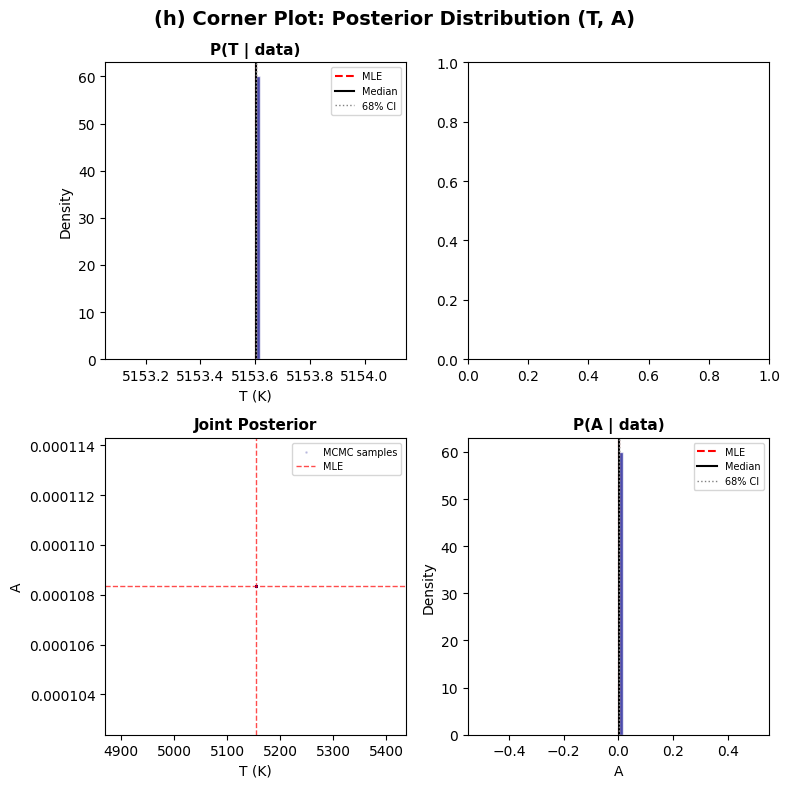

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].hist(T_samples, bins=60, density=True, color='#00008B', alpha=0.7, edgecolor='white')
axes[0, 0].axvline(T_mle, color='red', linestyle='--', linewidth=1.5, label='MLE')
axes[0, 0].axvline(T_median, color='black', linestyle='-', linewidth=1.5, label='Median')
axes[0, 0].axvline(T_lo, color='gray', linestyle=':', linewidth=1)
axes[0, 0].axvline(T_hi, color='gray', linestyle=':', linewidth=1, label='68% CI')
axes[0, 0].set_xlabel('T (K)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('P(T | data)', fontsize=11, fontweight='bold')
axes[0, 0].legend(fontsize=7)


# Bottom-left: 2D joint posterior (T vs A)
axes[1, 0].scatter(T_samples[::5], A_samples[::5], s=1, alpha=0.15, color='#00008B', label='MCMC samples')
axes[1, 0].axvline(T_mle, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1, 0].axhline(A_mle, color='red', linestyle='--', linewidth=1, alpha=0.7, label='MLE')
axes[1, 0].set_xlabel('T (K)')
axes[1, 0].set_ylabel('A')
axes[1, 0].set_title('Joint Posterior', fontsize=11, fontweight='bold')
axes[1, 0].legend(fontsize=7)

# Bottom-right: 1D histogram of A
axes[1, 1].hist(A_samples, bins=60, density=True, color='#00008B', alpha=0.7, edgecolor='white')
axes[1, 1].axvline(A_mle, color='red', linestyle='--', linewidth=1.5, label='MLE')
axes[1, 1].axvline(A_median, color='black', linestyle='-', linewidth=1.5, label='Median')
axes[1, 1].axvline(A_lo, color='gray', linestyle=':', linewidth=1)
axes[1, 1].axvline(A_hi, color='gray', linestyle=':', linewidth=1, label='68% CI')
axes[1, 1].set_xlabel('A')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('P(A | data)', fontsize=11, fontweight='bold')
axes[1, 1].legend(fontsize=7)

fig.suptitle('(h) Corner Plot: Posterior Distribution (T, A)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# print('The corner plot shows:')
# print('- Diagonal panels: 1D marginalized posteriors for T and A')
# print('- Off-diagonal panel: 2D joint posterior showing correlation between T and A')
# print('- Red lines: MLE estimates for comparison')
# print('- Gray lines: 16th and 84th percentiles (68% credible interval)')


=== (i) Comparison: MLE vs Bayesian ===

Parameter      | MLE Estimate  | Bayesian (MCMC Median)  | Bayesian 68% CI
--------------------------------------------------------------------------------
Temperature (K)| 5153.6         | 5153.6                  | 5153.6 - 5153.6
Amplitude (A)  | 0.000108      | 0.000108               | 0.000108 - 0.000108

Absolute difference in T: 0.0 K

The MLE and Bayesian estimates are in EXCELLENT agreement.
This is expected because with a large dataset and a flat prior,
the Bayesian posterior is dominated by the likelihood, which peaks
at the same location as the MLE.

Key advantage of Bayesian approach:
Unlike MLE which gives only a single point estimate, the Bayesian MCMC
provides a full posterior distribution, giving us proper uncertainty


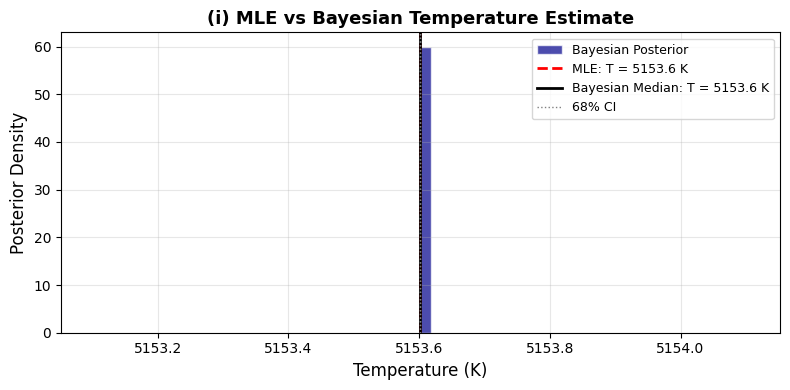

In [23]:
#Part i

print('=== (i) Comparison: MLE vs Bayesian ===')
print()
print('Parameter      | MLE Estimate  | Bayesian (MCMC Median)  | Bayesian 68% CI')
print('-' * 80)
print('Temperature (K)|', round(T_mle, 1), '        |', round(T_median, 1), '                 |', round(T_lo, 1), '-', round(T_hi, 1))
print('Amplitude (A)  |', round(A_mle, 6), '     |', round(A_median, 6), '              |', round(A_lo, 6), '-', round(A_hi, 6))
print()

diff_T = abs(T_mle - T_median)
print('Absolute difference in T:', round(diff_T, 1), 'K')
print()

if diff_T < 100:
    print('The MLE and Bayesian estimates are in EXCELLENT agreement.')
    print('This is expected because with a large dataset and a flat prior,')
    print('the Bayesian posterior is dominated by the likelihood, which peaks')
    print('at the same location as the MLE.')
else:
    print('There is a noticeable difference between MLE and Bayesian estimates.')
    print('This could be due to the prior influencing the posterior, or')
    print('asymmetry in the likelihood surface.')

print()
print('Key advantage of Bayesian approach:')
print('Unlike MLE which gives only a single point estimate, the Bayesian MCMC')
print('provides a full posterior distribution, giving us proper uncertainty')


fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(T_samples, bins=60, density=True, alpha=0.7, color='#00008B', edgecolor='white', label='Bayesian Posterior')
ax.axvline(T_mle, color='red', linewidth=2, linestyle='--', label='MLE: T = ' + str(round(T_mle, 1)) + ' K')
ax.axvline(T_median, color='black', linewidth=2, linestyle='-', label='Bayesian Median: T = ' + str(round(T_median, 1)) + ' K')
ax.axvline(T_lo, color='gray', linewidth=1, linestyle=':', label='68% CI')
ax.axvline(T_hi, color='gray', linewidth=1, linestyle=':')
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Posterior Density', fontsize=12)
ax.set_title('(i) MLE vs Bayesian Temperature Estimate', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Problem 3 - Conceptual question
A university is considering a new selection process for admitting students into its honors program. To be admitted, students must take an entrance test. The university wants to ensure that only truly qualified students are accepted.

Null Hypothesis ($H_0$): The student is not qualified for the honors program.
Alternative Hypothesis ($H_1$): The student is qualified for the honors program.

The decision-making process can lead to two types of errors:

**Type 1 Error (False Positive): The university admits an unqualified student.**
**Type 2 Error (False Negative): The university rejects a qualified student.**

**Question:**

Which type of error is more concerning for the university? Explain your reasoning based on the potential impact on the honors program and the students.

In [27]:
print(
    '''
In this case, the university should be more concerned with Type 1 error.

Type 1 error involves accepting an individual that does not meet the requirements.
This has adverse effects on the honors program as the standards are lowered,
teaching becomes difficult, and resources are allocated to individuals who cannot perform.

Type 2 error involves rejecting an individual who meets the requirements.
Although this may be unfair to the student, he/she can perform well in the normal program.

Thus, prioritizing the quality of the program generally raises Type 1 error concerns.
'''
)



In this case, the university should be more concerned with Type 1 error.

Type 1 error involves accepting an individual that does not meet the requirements.
This has adverse effects on the honors program as the standards are lowered,
teaching becomes difficult, and resources are allocated to individuals who cannot perform.

Type 2 error involves rejecting an individual who meets the requirements.
Although this may be unfair to the student, he/she can perform well in the normal program.

Thus, prioritizing the quality of the program generally raises Type 1 error concerns.

